# CNN-based cell cycle analysis
The Notebook is structured into 2 parts:
- Part1: Model performance for gene discovery
- Part2: Model predictive performance

All plots are placed in the folder `./plots`

## Input files
The notebook by default runs on pre computed results as shown in the manuscript which are located in the folder `../input_files`. 

Additional files that need to be included in the `input_files` folder are: 
- Fucci dataset: `fucci_final.h5` 
- Seed1 training results for cell shape model:`test_preds_seg_s1.h5ad`
- Seed1 training results for nuclear model: `test_preds_hoechst_s1.h5ad`

For the analysis of recomputed results these files have to be replaced.
- Section 1:
    - Path variable `path_model_perf` with `all_channels_results_qc_clean.csv` from results from `DeepLearning_pipeline`
    - Path variable `window_df` with `DEGs_x_window.tsv` from results from `scRNAse_analysis`

- Section 2:
    - Path variable `path_adata_seg` with `test_preds_seg_s1.h5ad`
    - Path variable `path_adata_hoechst` with `test_preds_hoechst_s1.h5ad`

In [1]:
# Imports
import pandas as pd
import seaborn as sns
import numpy as np
import scanpy as sc
import os
import gseapy as gp
import h5py
import cv2
import skimage as ski
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text
import pylab as plt
from matplotlib_venn import venn3, venn3_circles
import matplotlib.colors as mcolors

In [2]:
## Section 1 : 
# Inputs
path_model_perf = f'../input_files/all_channels_results_qc_clean.csv' # Example file
#path_model_perf = f'../output_files/all_channels_results_qc_clean.csv' # If you ran previous snippet ../DeepLearning_pipeline/compile_scores.ipynb

# Outputs
output_data_path = f'../output_files/'
os.makedirs(output_data_path, exist_ok=True)
output_fig_path = f'../output_files/plots'
os.makedirs(output_fig_path, exist_ok=True)

## Section 2 : CNN prediction analysis
# Test predicition datasets
path_adata_seg = '../input_files/test_preds_seg_s1.h5ad' # Example file
#path_adata_seg = '../output_files/fucci_final_seg-bg-random_resnet/seed_0/test_preds.h5ad' # If you ran previous snippet ../DeepLearning_pipeline/compile_scores.ipynb
path_adata_hoechst = '../input_files/test_preds_hoechst_s1.h5ad' # Example file
#path_adata_hoechst = '../output_files/fucci_final_405-random_resnet/seed_0/test_preds.h5ad' # If you ran previous snippet ../DeepLearning_pipeline/compile_scores.ipynb

# Cell id exclusion lists
path_white_list = '../input_files/cid_whitelist.csv'
path_nuc_remove = '../input_files/cid_nuc_toremove.csv'

# Path to the hdf5 dataset
ds_dir = "../input_files/fucci_final.h5"

## Other parameters
# Extraction of some performance metrics reported in the manuscript
metrics = ["avg_Pearson", "avg_Pearson_fdr"]
features = ["FUCCI angle", "Hoechst", "Segmentation"]

# DEG Window file of DE genes in angular bins
path_deg_window = "../input_files/DEGs_x_window.tsv"

# Significance threshold used
p_tresh = 0.01

In [3]:
all_feat_df = pd.read_csv(path_model_perf, header=[0, 1], index_col=0)
cols = [(m, f) for f in features for m in metrics]
all_feat_df = all_feat_df[cols]
all_feat_df

,avg_Pearson,avg_Pearson_fdr,avg_Pearson,avg_Pearson_fdr,avg_Pearson,avg_Pearson_fdr
channel,FUCCI angle,FUCCI angle,Hoechst,Hoechst,Segmentation,Segmentation
genes,,,,,,
1110032A03Rik,-0.020642,9.908342e-01,-0.013767,6.007592e-01,0.007666,8.927352e-01
1190007I07Rik,0.016679,9.900810e-01,0.028992,6.663881e-01,0.022723,4.866776e-01
1500026H17Rik,0.035788,4.251726e-01,-0.012633,7.453716e-01,-0.007771,8.445120e-01
1600010M07Rik,0.058833,4.360411e-01,0.050859,8.391743e-02,0.071041,2.685695e-02
1600019K03Rik,0.109234,3.844170e-06,0.141019,3.444095e-08,0.192132,6.548844e-20
...,...,...,...,...,...,...
mt-Rnr2,0.193563,1.292328e-18,0.105240,7.782137e-06,0.198858,2.971636e-19
mt-Tf,0.013685,2.841170e-01,-0.000034,6.589488e-01,-0.002509,3.903236e-01


In [4]:
avg_pearson = {}
cols = [((m1, f), (m2, f)) for m1, m2 in [metrics] for f in features]
for pearson, pval in cols:
    col_label = pearson[1]
    series = all_feat_df[pearson]
    
    num_sig = len(all_feat_df[all_feat_df[pval] < p_tresh].index.tolist())
    
    # Max value and corresponding gene and Top 100 selection
    max_val = series.max()
    max_gene = series.idxmax()
    
    top100 = series.sort_values(ascending=False).head(100)
    avg_top100 = top100.mean()
    
    # Print results
    print(f"Column: {col_label}")
    print(f"  ➤ Best gene: {max_gene}")
    print(f"  ➤ Gene r value: {max_val:.2f}")
    print(f"  ➤ Mean of top 100 values: {avg_top100:.2f}")
    print(f"  ➤ Num genes below {p_tresh}: {num_sig:.0f}")
    
    avg_pearson[col_label] = avg_top100

rel_segmentation = avg_pearson['Segmentation']/avg_pearson['FUCCI angle']
rel_hoechst = avg_pearson['Hoechst']/avg_pearson['FUCCI angle']

print(f"  ➤ Relative segmentation performance: {rel_segmentation}")
print(f"  ➤ Hoechst segmentation performance: {rel_hoechst}")

Column: FUCCI angle
  ➤ Best gene: Top2a
  ➤ Gene r value: 0.76
  ➤ Mean of top 100 values: 0.40
  ➤ Num genes below 0.01: 343
Column: Hoechst
  ➤ Best gene: Top2a
  ➤ Gene r value: 0.37
  ➤ Mean of top 100 values: 0.16
  ➤ Num genes below 0.01: 203
Column: Segmentation
  ➤ Best gene: Prc1
  ➤ Gene r value: 0.38
  ➤ Mean of top 100 values: 0.19
  ➤ Num genes below 0.01: 332
  ➤ Relative segmentation performance: 0.4683950569701624
  ➤ Hoechst segmentation performance: 0.3874317718076714


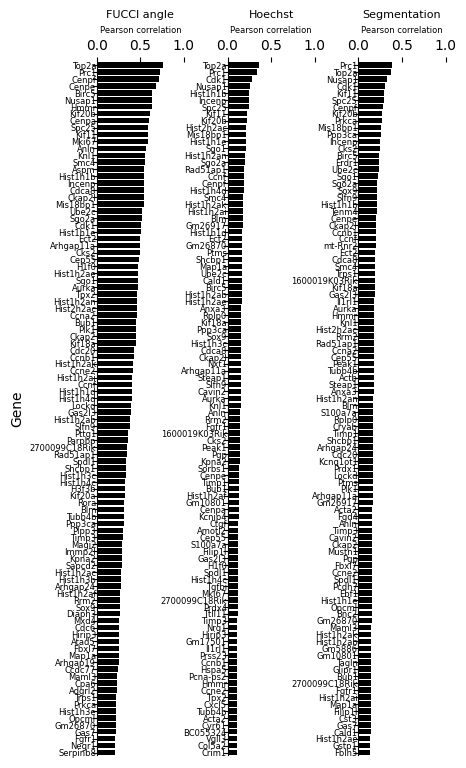

In [5]:
cols = [("avg_Pearson", f) for f in features]

# Bar chart of top100 best genes for each model
fig, axes = plt.subplots(
    1, len(cols), 
    figsize=(len(cols)*1.5, 9), 
    sharex=False,  # Share x-axis (Window)
)

# Plot each column
for plt_id, (col, ax) in enumerate(zip(cols, axes)):
    # Get data for top 100 genes 
    col_label = col[1]
    series = all_feat_df[col].sort_values(ascending=False).head(100)

    # Setup plot
    ax.grid(False)
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_color('none')    

    # barh takes y positions (range) and values
    y_pos = np.arange(len(series))
    ax.barh(series.index, series, color='black')

    # Move y-axis label and ticks to the right
    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()
    ax.set_xlabel('Pearson correlation', size=6) 
    
    if plt_id == 0:
        ax.set_ylabel("Gene")
    else:
        ax.set_ylabel("")
        
    # Invert y-axis (highest value at the top, optional)
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=6, pad=-3)

    ax.margins(y=0)         # removes horizontal padding
    ax.margins(x=0.5)         # removes horizontal padding
    
    ax.set_xlim(xmin=0, xmax=1)
    ax.set_title(col_label, size=8)

fig.subplots_adjust(wspace=0.5)
plt.savefig(f'{output_fig_path}/ML_Bar_PearsonCor_{col_label}.pdf', transparent=True, bbox_inches = 'tight') 
plt.show()

# Figure 5B: Morphology model performance over angular bin
1. DE-genes per angular bin as derived in Figure 4 serve as reference list (bar chart)
2. For all genes in one bins the morphologies performance is averaged

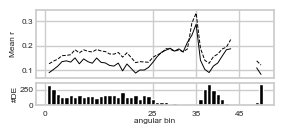

In [6]:
window_df = pd.read_csv(path_deg_window, sep='\t')
w1_list = window_df[window_df['group'] == 1]['names'].tolist()

num_per_window = window_df['group'].value_counts().sort_index().to_frame()

window_grp = window_df.groupby('group')

sub_feat_df = all_feat_df[cols]
sub_feat_df.columns = sub_feat_df.columns.droplevel(0)

window_df = window_df.set_index('names')

# Merge on index
window_pred_merge_df = sub_feat_df.merge(window_df, left_index=True, right_index=True)
window_pred_merge_df = window_pred_merge_df.dropna()
mean_window = window_pred_merge_df.groupby(['group'])[['Hoechst', 'Segmentation']].mean()

mean_window = mean_window.merge(num_per_window, left_index=True, right_index=True)
mean_window = mean_window.reindex(range(mean_window.index.min(), mean_window.index.max()+1)).reset_index()
mean_window.rename(columns={'group': 'Window'}, inplace=True)

mean_window_long = mean_window.melt(id_vars=['Window', 'count'], value_vars=['Hoechst', 'Segmentation'], var_name='Measurement', value_name='Value')

# Set Seaborn style
sns.set(style="whitegrid")

# Create subplots: top for lines, bottom for bars
fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(3, 1.5), 
    sharex=True,  # Share x-axis (Window)
    gridspec_kw={'height_ratios': [3, 1]}  # Line plot taller than bar
)

# === LINE PLOT ===
styles = {"Hoechst": "solid", "Segmentation": "dashed"}

for measurement, subdf in mean_window_long.groupby("Measurement"):
    # Find contiguous runs without NaN
    mask = subdf["Value"].notna()
    # Split on NaNs
    for _, block in subdf[mask].groupby((~mask).cumsum()):
        sns.lineplot(
            data=block,
            x="Window",
            y="Value",
            linestyle = styles[measurement],
            label=measurement,
            ax=ax1,
            color='black',
            linewidth = 0.7
        )

ax1.set_title('')
ax1.set_ylabel('Mean r', fontsize=6)
legend = ax1.legend(title='Measurement', loc='center left', bbox_to_anchor=(1.02, 0.5))
ax1.get_legend().remove()
legend.set_frame_on(False)

# === BAR PLOT ===
# One bar per window (aggregated once per row already)
df_bar = mean_window[['Window', 'count']]
ax2.bar(df_bar['Window'], df_bar['count'], width=1.0, color='black')
ax2.set_ylabel('#DE', fontsize=6, labelpad=1)
ax2.set_xlabel('angular bin', fontsize=6, labelpad=1)
ax2.set_title('')
ax2.tick_params(axis='x', pad=-2)
ax2.tick_params(axis='y', pad=-2)

ax1.tick_params(axis='y', pad=-2)
ax1.set_xticks([0,25,35,45])
ax1.tick_params(axis='y', labelsize=6, length=2, pad=0)
ax2.tick_params(axis='y', labelsize=6, length=2, pad=0)
ax2.tick_params(axis='x', labelsize=6, length=2, pad=2)

plt.xticks(fontsize=6)

# Reduce vertical spacing
plt.tight_layout(h_pad=0.3)
plt.savefig(f'{output_fig_path}/ML_Line_WindowPerformance.pdf', transparent=True, bbox_inches = 'tight') 
plt.show()

## Figure 5C/D: Comparison of genes discovered by models
- First cell: Identification of all significant genes and basics statistics.
- Second cell: Plotting of Venn diagram (Figure 5C)
- Third cell: Generation of Venn diagram classes for gene PCA. For Figure 5D. Plotted in Figure 4 Notebook.

In [7]:
all_genes = all_feat_df.index.to_list()

# List of significant genes for each model
Segmentation_genes = all_feat_df[all_feat_df[('avg_Pearson_fdr', 'Segmentation')] < p_tresh].index.to_list()
Hoechst_genes = all_feat_df[all_feat_df[('avg_Pearson_fdr', 'Hoechst')] < p_tresh].index.to_list()
Angular_genes = all_feat_df[all_feat_df[('avg_Pearson_fdr', 'FUCCI angle')] < p_tresh].index.to_list()

all_sig_genes = set(Hoechst_genes + Angular_genes + Segmentation_genes)
num_all_sig = len(all_sig_genes)

# Print numbers:
print(f"  ➤ # of all significant genes: {num_all_sig}")
print(f"  ➤ All cycle genes: {len(Angular_genes)}")

morph_genes = set(Hoechst_genes + Segmentation_genes)
morph_only_genes = morph_genes - set(Angular_genes)
morph_only_perc = round(len(morph_only_genes)/num_all_sig, 4)

print(f"  ➤ Fraction morphology model only genes: {morph_only_perc}")

cycling_perc = round(len(Angular_genes)/num_all_sig, 4)

print(f"  ➤ Fraction cycle: {cycling_perc}")

morph_cycling_genes = list(set(Angular_genes) & set(morph_genes))
morph_cycling_percdiscov = round(len(morph_cycling_genes)/len(Angular_genes), 4)
print(f"  ➤ Fraction cycle genes with morph model: {morph_cycling_percdiscov}")

  ➤ # of all significant genes: 462
  ➤ All cycle genes: 343
  ➤ Fraction morphology model only genes: 0.2576
  ➤ Fraction cycle: 0.7424
  ➤ Fraction cycle genes with morph model: 0.6822


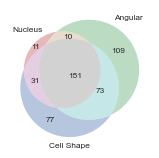

In [8]:
# Create sets
A = set(Hoechst_genes)
B = set(Angular_genes)
C = set(Segmentation_genes)

# Create the Venn diagram
fig, axes = plt.subplots(1, 1, figsize=(1.8, 1.8)) 
venn = venn3((A, B, C), ('Nucleus', 'Angular', 'Cell Shape'))

for text in venn.set_labels:
    text.set_fontsize(6)
for text in venn.subset_labels:
    text.set_fontsize(6)

plt.savefig(f'{output_fig_path}/ML_Venn_Genes.pdf', transparent=True, bbox_inches = 'tight') 

In [9]:
# Region codes (order matches venn3 internal patch order)
region_codes = ['100', '010', '110', '001', '101', '011', '111']

# Mapping from region code to color
region_to_color = {}
for code, patch in zip(region_codes, venn.patches):
    if patch:
        rgba = patch.get_facecolor()
        hex_color = mcolors.to_hex(rgba)
        region_to_color[code] = hex_color

# Function to determine region code for a gene
def get_region_code(gene):
    in_A = gene in A
    in_B = gene in B
    in_C = gene in C
    return f"{int(in_A)}{int(in_B)}{int(in_C)}"

# Combine all genes
all_genes = A | B | C

# Create DataFrame
data = []
for gene in all_genes:
    region = get_region_code(gene)
    color = region_to_color.get(region, "#FFFFFF")  # fallback to white if region is missing
    data.append({'gene': gene, 'region': region, 'color': color})

df = pd.DataFrame(data)
print(df)
df.to_csv(f'{output_data_path}/venn_gene_regions.csv', index=False)

         gene region    color
0        Smc4    111  #8f9091
1     Gm10184    011  #71c5c4
2      Sorbs1    111  #8f9091
3      Pcdh10    010  #55a868
4    Trappc6b    001  #4c72b0
..        ...    ...      ...
457   Galnt18    010  #55a868
458      Ccnf    111  #8f9091
459    Diaph3    111  #8f9091
460      Ccl7    010  #55a868
461  Hist1h4c    111  #8f9091

[462 rows x 3 columns]


In [10]:
rel_gene_df = all_feat_df.copy()

# Select genes that are significant in either morphology model.
top_genes = all_feat_df[(all_feat_df[('avg_Pearson_fdr', 'Segmentation')] < p_tresh) | 
                        (all_feat_df[('avg_Pearson_fdr', 'Hoechst')] < p_tresh)].index.tolist()
                         
top_genes = set(top_genes)

# Extract subframe for processing and drop level
rel_gene_df = rel_gene_df[rel_gene_df.index.isin(top_genes)]
rel_gene_df = rel_gene_df[cols]

rel_gene_df.columns = rel_gene_df.columns.droplevel(0)
rel_gene_df_norm = rel_gene_df

# Max normalize each column
rel_gene_df_norm['seg_norm'] = rel_gene_df['Segmentation'] / rel_gene_df['Segmentation'].max()
rel_gene_df_norm['hoechst_norm'] = rel_gene_df['Hoechst'] / rel_gene_df['Hoechst'].max()
rel_gene_df_norm['angle_norm'] = rel_gene_df['FUCCI angle'] / rel_gene_df['FUCCI angle'].max()
print("Sanity check: Normalized columns should be max == 0")
print(rel_gene_df_norm.max(0))

# Relative against Fucci angle
rel_gene_df_norm['rel_seg'] = abs(rel_gene_df_norm['seg_norm']) / abs(rel_gene_df_norm['FUCCI angle'])
rel_gene_df_norm['rel_hoechst'] = abs(rel_gene_df_norm['hoechst_norm']) / abs(rel_gene_df_norm['FUCCI angle'])
print(rel_gene_df_norm)

Sanity check: Normalized columns should be max == 0
channel
FUCCI angle     0.757116
Hoechst         0.366358
Segmentation    0.383681
seg_norm        1.000000
hoechst_norm    1.000000
angle_norm      1.000000
dtype: float64
channel        FUCCI angle   Hoechst  Segmentation  seg_norm  hoechst_norm  \
genes                                                                        
1600019K03Rik     0.109234  0.141019      0.192132  0.500759      0.384921   
1700111N16Rik    -0.020142 -0.052607     -0.004345 -0.011325     -0.143594   
2310033P09Rik     0.066768  0.074712      0.097856  0.255045      0.203932   
2410006H16Rik     0.027945  0.027548      0.035048  0.091347      0.075193   
2700099C18Rik     0.347107  0.115812      0.144374  0.376285      0.316116   
...                    ...       ...           ...       ...           ...   
mt-Atp8           0.089347  0.048791      0.106849  0.278485      0.133179   
mt-Nd6            0.040464  0.037390      0.074245  0.193508      0.10205

In [11]:
# Plotting function 
def plt_rel_pred_perf(to_plot, fold=None, max_genes=None, color=None):
    # Sort and filter
    plot_df = rel_gene_df_norm.sort_values(by=to_plot)
    if fold:
        plot_df = plot_df[(plot_df[to_plot] > fold) | (plot_df[to_plot] < (1/fold))]
        
    if max_genes:
        plot_df[to_plot +'_abs_fold'] = plot_df[to_plot].apply(lambda x: x if x >= 1 else 1/x)
        plot_df = plot_df.nlargest(max_genes, to_plot +'_abs_fold')
        
    plot_df = plot_df.sort_values(by=to_plot)
    
    if color:
        neg_color, pos_color = color
        plot_df['color'] = plot_df[to_plot].apply(lambda x: pos_color if x >= 1 else neg_color)
        color_dict = {neg_color: neg_color, pos_color: pos_color}
    else:
        plot_df['color'] = 'black'
        color_dict = {'black': 'black'}

    # Determine raw column
    if "seg" in to_plot:
        raw_col = "Segmentation"
    elif "hoechst" in to_plot:
        raw_col = "Hoechst"
    else:
        raw_col = None

    fig, ax = plt.subplots(figsize=(1.5,5), dpi=200)

    sns.barplot(
        data=plot_df,
        x=np.log(plot_df[to_plot]),
        y=plot_df.index,
        orient="y",
        hue=plot_df.color,
        palette=color_dict,
        width = 1, 
        dodge=False,
        ax=ax,
        clip_on=False
    )
    ax.axvline(0, color='black', linewidth=0.3)
    ax.set_xlabel("log10(rel. performance)", fontsize=6)
    ax.set_ylabel("")
    ax.tick_params(axis='y', which='both', length=0, labelsize=5)
    ax.tick_params(axis='x', direction='out', length=3, width=0.5, labelsize=5)
    sns.despine(ax=ax, left=True, bottom=False)
    ax.legend([],[], frameon=False)

    # --- Secondary axis with distinct scaling ---
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())  # full width matches bar chart

    # Define distinct scales
    angle_min, angle_max = 0, 0.3
    raw_min, raw_max = 0, 0.3

    # Map FUCCI and raw values to bar chart scale
    max_abs = max(abs(plot_df[to_plot].apply(np.log).min()), 
                  abs(plot_df[to_plot].apply(np.log).max()))
    bar_xlim = ax.get_xlim()
    print("Bar xlimg:", bar_xlim)
    def scale_left(val):

        return np.interp(val, [angle_min, angle_max], [0, -bar_xlim[1]])
    def scale_right(val):
        return np.interp(val, [raw_min, raw_max], [0, bar_xlim[1]])
    
    angle_ticks = [angle_min, angle_max]
    raw_ticks = [raw_min, raw_max]
    
    ax2.set_xticks([scale_left(t) for t in angle_ticks] + [scale_right(t) for t in raw_ticks])
    ax2.set_xticklabels([f"{t:.2f}" for t in angle_ticks] + [f"{t:.2f}" for t in raw_ticks])

    for i, (idx, row) in enumerate(plot_df.iterrows()):
        x1 = scale_left(row['FUCCI angle'])
        x2 = scale_right(row[raw_col])
        bar_col = row['color']

        ax2.scatter(x1, i, color="black", s=0.5,  zorder=5)
        ax2.scatter(x2, i, color="black", s=0.5, zorder=5)

    ax2.set_xlabel("", fontsize=6)
    ax2.tick_params(axis='x', labelsize=5)
    ax2.grid(False)
    ax.grid(False)
    ax.set_xlim(-max_abs, max_abs)
    ax2.set_xlim(-bar_xlim[1], bar_xlim[1])
    bar_xlim = ax.get_xlim()
    
    ax.margins(y=0)
    
    plt.tick_params(
        axis='x',        # only x-axis
        direction='out',
        length=3,
        width=0.5,
        color='black',
        pad=0.1
    )
    
    sns.despine(ax=ax2, left=True, bottom=False)

    plt.tight_layout()
    return plt

Bar xlimg: (-3.88766672273129, 7.045835680877156)


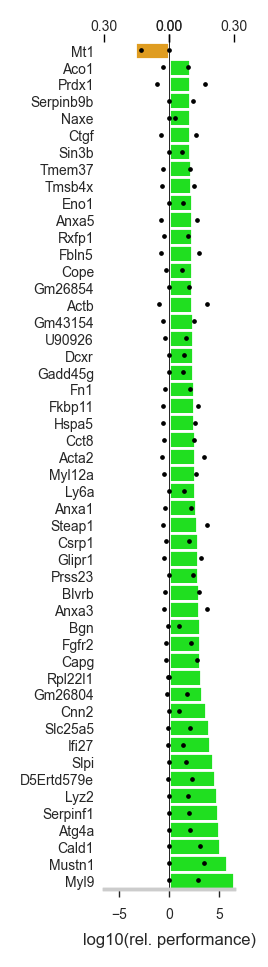

In [12]:
fold_perform = 10

seg_color = 'lime'
hoechst_color = 'teal'
angular_color = 'orange'

plt = plt_rel_pred_perf('rel_seg', max_genes=50, color=(angular_color, seg_color))
plt.savefig(f'{output_fig_path}/ML_Bar_RelPerf_Seg.pdf', transparent=True, bbox_inches = 'tight') 
plt.show()

Bar xlimg: (-6.528411480879538, 6.385295032878134)


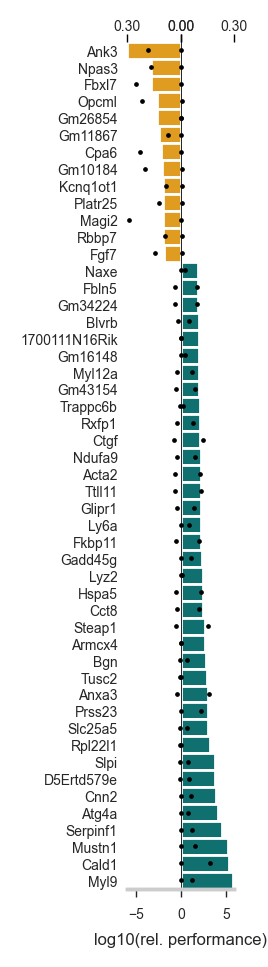

In [13]:
plt = plt_rel_pred_perf('rel_hoechst', max_genes=50, color=(angular_color, hoechst_color))
plt.savefig(f'{output_fig_path}/ML_Bar_RelPerf_Hoechst.pdf', transparent=True, bbox_inches = 'tight') 
plt.show()

## Figure 5F: GSEA of Morphology genes

- Cell 1: Utility functions for GSEA 
- Cell 2: GSEA for nucleus segmentation mask (cell shape) genes
- Cell 2: GSEA for nucleus Hoechst (nucleus) genes

In [14]:
fold_perform = 2

# Utility function for term formatting.
def format_term(term):
    parts = term.rsplit(' ', 1)
    name = parts[0]
    pathway_id = parts[1]

    # Split the name into words and break into 2-3 lines
    name_words = name.split()
    # You can adjust grouping below
    if len(name_words) <= 2:
        name_lines = [' '.join(name_words)]
    elif len(name_words) == 3:
        name_lines = [' '.join(name_words[:2]), name_words[2]]
    else:
        name_lines = [' '.join(name_words[:2]), ' '.join(name_words[2:])]

    # Italicize name lines using LaTeX
    italic_lines = [r"$\it{" + line + "}$" for line in name_lines]
    
    # Combine with ID (not italic)
    return "\n".join(name_lines + [r"$\it{" + pathway_id + "}$"])

# Utility function for GSEA
def enrich_list(gene_list):
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets='Reactome_2022',
        organism='Mouse',
        outdir=None  # No file output
        )
    enr.results['-log10(Adjusted P-value)'] = -np.log10(enr.results['Adjusted P-value'])
    df = enr.results.sort_values('Adjusted P-value').head(3)
    df['formatted_term'] = df['Term'].apply(format_term)
    return df

                                     Term Overlap  Adjusted P-value  \
0  Smooth Muscle Contraction R-HSA-445355    8/43      4.455716e-07   
1         Muscle Contraction R-HSA-397014  10/196      5.035132e-04   
2     Platelet Degranulation R-HSA-114608   8/125      7.390353e-04   

                                               Genes  
0     ACTA2;ANXA1;CALD1;TPM2;PXDN;SORBS1;MYL9;MYL12A  
1  ACTA2;CAMK2B;ANXA1;CALD1;TPM2;KCNIP4;PXDN;SORB...  
2       CD63;HSPA5;TMSB4X;ANXA5;FN1;PPBP;TIMP1;THBS1  


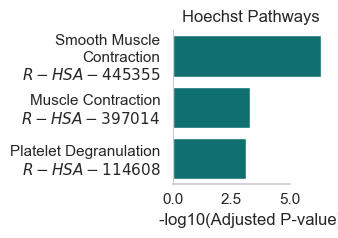

In [16]:
hoechst_genes = rel_gene_df_norm[rel_gene_df_norm['rel_hoechst'] > fold_perform].index.tolist()
hoechst_enr_df = enrich_list(hoechst_genes)
print(hoechst_enr_df[['Term', 'Overlap', 'Adjusted P-value', 'Genes']])

# Plot
plt.figure(figsize=(2, 2))
b = sns.barplot(
    data=hoechst_enr_df,
    y='formatted_term',
    x='-log10(Adjusted P-value)',
    color = hoechst_color
)

plt.title('Hoechst Pathways')
plt.xlabel('-log10(Adjusted P-value)')
plt.ylabel('')

sns.despine(trim=True, bottom=False, top=True, right=True, left=True)
b.axvline(0, color='black', linewidth=0.3)

plt.tick_params(
    axis='x',        # only x-axis
    direction='out',
    length=3,
    width=0.5,
    color='black'
)
b.grid(False)
plt.savefig(f'{output_fig_path}/ML_Bar_GSEA_Hoechst.pdf', transparent=True, bbox_inches = 'tight') 
plt.show()

                                                Term Overlap  \
0             Smooth Muscle Contraction R-HSA-445355    8/43   
1  Response To Elevated Platelet Cytosolic Ca2+ R...  11/130   
2                Platelet Degranulation R-HSA-114608  10/125   

   Adjusted P-value                                              Genes  
0          0.000006      ACTA2;ANXA1;ANXA2;CALD1;TPM2;PXDN;MYL9;MYL12A  
1          0.000023  CD63;HSPA5;TMSB4X;PCDH7;ANXA5;FN1;PRKCA;PPBP;T...  
2          0.000107  CD63;HSPA5;TMSB4X;PCDH7;ANXA5;FN1;PPBP;TIMP1;P...  


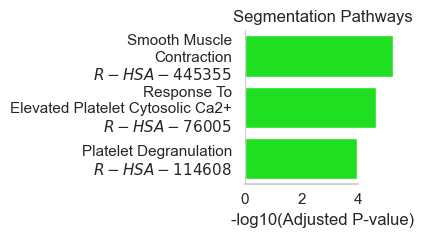

In [17]:
seg_genes = rel_gene_df_norm[rel_gene_df_norm['rel_seg'] > fold_perform].index.tolist()
seg_enr_df = enrich_list(seg_genes)
print(seg_enr_df[['Term', 'Overlap', 'Adjusted P-value', 'Genes']])

# Plot
plt.figure(figsize=(2, 2))
b = sns.barplot(
    data=seg_enr_df,
    y='formatted_term',
    x='-log10(Adjusted P-value)',
    color = seg_color
)

plt.title('Segmentation Pathways')
plt.xlabel('-log10(Adjusted P-value)')
plt.ylabel('')

sns.despine(trim=True, bottom=False, top=True, right=True, left=True)
b.axvline(0, color='black', linewidth=0.3)

plt.tick_params(
    axis='x',
    direction='out',
    length=3,
    width=0.5,
    color='black'
)

b.grid(False)
plt.savefig(f'{output_fig_path}/ML_Bar_GSEA_Seg.pdf', transparent=True, bbox_inches = 'tight') 
plt.show()

# Section 2: CNN prediction analysis 
1. Load and filter data:
    - Load data 
    - Load inclusion and exclusion lists.
    - filter data by lists
2. Define plotting functions for Figure5 G/H

In [18]:
# Step1: Load data
adata_seg = sc.read_h5ad(path_adata_seg)
adata_hoechst = sc.read_h5ad(path_adata_hoechst)

# List of all qced cells from sc analysis
white_list = pd.read_csv(path_white_list)

# Cells that are fragmented, cluster 7
nuclei = pd.read_csv(path_nuc_remove)

white_list = [item for item in white_list if item not in nuclei]

adata_seg = adata_seg[adata_seg.obs_names.isin(white_list)].copy()
adata_hoechst = adata_hoechst[adata_hoechst.obs_names.isin(white_list)].copy()

### Figure5G: Actual vs Predicted with density overlay
1. Cell1: Defines plotting utility function
2. Cell2: Data visualization

In [19]:
# Scatters actual vs predicted expression with density color map
def predVraw_scatter_density(adata, gene_name, highlights = None, ax = None):   
    if ax is not None:
        axes = ax
    else:
        fig, axes = plt.subplots(1, 1, figsize=(10, 5)) 
        
    # Get data
    gene_idx = np.where(adata.var_names == gene)[0][0]
    x_raw = adata.X[:, gene_idx]
    x_pred = adata.layers['pred'][:, gene_idx]
    
    x = x_raw
    y = x_pred

    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]

    scatter = ax.scatter(x, y, c=z, s=5, cmap='viridis', alpha=0.7)

    # Overlay density contours
    sns.kdeplot(x=x, y=y, levels=10, color='black', linewidths=0.5, ax = ax)

    ax.tick_params(axis='x', which='major', pad=-2)
    ax.tick_params(axis='y', which='major', pad=-2)
    
    ax.set_xlabel("Raw expression")
    ax.set_ylabel("Predicted expression")  

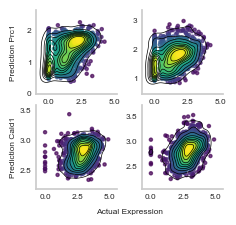

In [20]:
# Example gene
genes = ['Prc1', 'Cald1']

fig, axes = plt.subplots(2, 2, figsize=(2.7, 2.4))

for num, gene in enumerate(genes):
    col = num%2
    ax_seg = axes[col, 0]
    ax_hoechst = axes[col, 1]
    
    predVraw_scatter_density(adata_seg, gene, None, ax_seg)
    predVraw_scatter_density(adata_hoechst, gene, None, ax_hoechst)
    
    #for ax in [ax_seg, ax_hoechst]:
        #ax.legend().remove()

    ax_seg.set_xlabel('')
    ax_hoechst.set_xlabel('')
    ax_seg.set_ylabel('')
    ax_hoechst.set_ylabel('')
    
    ax_seg.text(
        -0.28,
        0.5,
        f'Prediction {gene}',
        rotation=90,
        va='center',
        ha='center',
        transform=ax_seg.transAxes,
        size=6,
    )
    
    ax_seg.grid(False)
    ax_seg.spines['right'].set_color('none')
    ax_seg.spines['top'].set_color('none')
    
    ax_hoechst.grid(False)
    ax_hoechst.spines['right'].set_color('none')
    ax_hoechst.spines['top'].set_color('none')
    
    ax_seg.tick_params(axis='y', labelsize=6, pad=-3)
    ax_seg.tick_params(axis='x', labelsize=6, pad=-3)
    
    ax_hoechst.tick_params(axis='y', labelsize=6, pad=-3)
    ax_hoechst.tick_params(axis='x', labelsize=6, pad=-3)
    
plt.tight_layout(h_pad=0, w_pad=0.5, pad = 1.5)
lbl = fig.supxlabel('Actual Expression',size = 6, x=0.55)  # common x-axis label
lbl.set_y(0.04) 
plt.savefig(f'{output_fig_path}/ML_Scatter_PredVsActual_Density.pdf', transparent=True, bbox_inches = 'tight') 
plt.show()

### Figure5H: Density distribution of Top/Bottom 10% expressers
1. Cell 1: Definition of the plotting function
2. Cell 2: Plotting

In [21]:
# Plots density distributions of Top/Bottom 10% acutal expressing cells against prediction.
def pred_vs_raw_density(adata, gene_name, perc, ax = None):
    if ax is not None:
        axes = ax
    else:
        fig, axes = plt.subplots(1, 1, figsize=(2, 2)) 
        
    gene_idx = np.where(adata.var_names == gene)[0][0]
    x_raw = adata.X[:, gene_idx]
    x_pred = adata.layers['pred'][:, gene_idx]
    # Step 1: Get indices of top 10 and bottom 10 of list1
    sorted_indices = np.argsort(x_raw)
    n = len(x_raw)
    k = max(1, int(n * perc/100))

    bottom10_indices = sorted_indices[:k]
    top10_indices = sorted_indices[-k:]
    
    print('Fraction considered: ', k/n)

    # Step 2: Get corresponding list2 values
    bottom10_values = [x_pred[i] for i in bottom10_indices]
    top10_values = [x_pred[i] for i in top10_indices]

    # Step 3: Plot KDE (density plot)

    sns.kdeplot(bottom10_values, label=f'Bottom 10 %', fill=True, color='blue', alpha=0.5, ax = axes)
    sns.kdeplot(top10_values, label=f'Top 10 %', fill=True, color='orange', alpha=0.5, ax = axes)

    axes.set_xlabel('Predicted expression')
    axes.set_ylabel('Frequency')
    axes.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.grid(True)

Fraction considered:  0.09931170108161258
Fraction considered:  0.09931170108161258
Fraction considered:  0.09931170108161258
Fraction considered:  0.09931170108161258


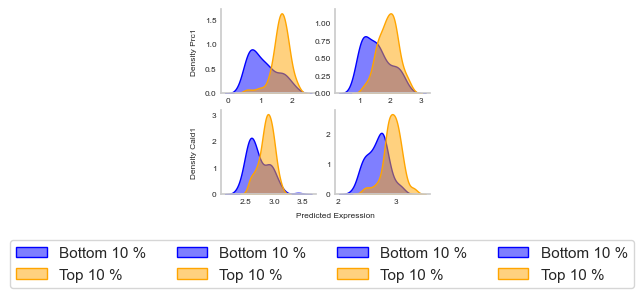

In [22]:
# Density distributions of Top/Bottom genes.
fig, axes = plt.subplots(2, 2, figsize=(2.7, 2.4))  
handles, labels = None, None # will hold the legend

for num, gene in enumerate(genes):
    col = num%2
    ax_seg = axes[col, 0]
    ax_hoechst = axes[col, 1]
    pred_vs_raw_density(adata_seg, gene, 10, ax_seg)
    pred_vs_raw_density(adata_hoechst, gene, 10, ax_hoechst)
        
    ax_seg.text(
        -0.28,                
        0.5,                 
        f'Density {gene}',
        rotation=90,
        va='center',
        ha='center',
        transform=ax_seg.transAxes,
        size=6,
    )
    
    # format axes
    for ax in (ax_seg, ax_hoechst):
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.grid(False)
        ax.spines['top'].set_color('none')
        ax.spines['right'].set_color('none')
        ax.tick_params(axis='x', labelsize=6, pad=-3)
        ax.tick_params(axis='y', labelsize=6, pad=-3)
    
lbl = fig.supxlabel('Predicted Expression',size = 6, x=0.55)  # common x-axis label
lbl.set_y(0.01) 

# Create a single legend outside the grid
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4)

for ax_1 in axes:
    for ax in ax_1:
        ax.legend().remove()

plt.savefig(f'{output_fig_path}/ML_Histogram_TopBot10_Density.pdf', transparent=True, bbox_inches = 'tight') 
plt.show()

### Figure5G (Supplement): Actual vs Predicted with batch highlights
1. Cell1: Definition of plotting function
2. Cell2: Plotting

In [23]:
# Scatters actual vs predicted expression with cell based color highlights
def predVraw_scatter_high(adata, gene_name, highlights = None, ax = None):   
    if ax is not None:
        axes = ax
    else:
        fig, axes = plt.subplots(1, 1, figsize=(10, 5)) 
        
    # Get data
    gene_idx = np.where(adata.var_names == gene)[0][0]
    x_raw = adata.X[:, gene_idx]
    x_pred = adata.layers['pred'][:, gene_idx]

    # Plot all points
    colors = sns.color_palette("hls", len(highlights))

    # Highlight selected cells
    if highlights:
        for label, color, cell_ids in highlights:
            indices = [adata.obs_names.get_loc(cell_id) for cell_id in cell_ids if cell_id in adata.obs_names]
            ax.scatter(x_raw[indices], x_pred[indices], color=color, s=5, label=label)

    ax.set_xlabel(f'Raw expression ({gene})')
    ax.set_ylabel(f'Predicted expression ({gene})')
    ax.legend(frameon=False)
    ax.grid(True)

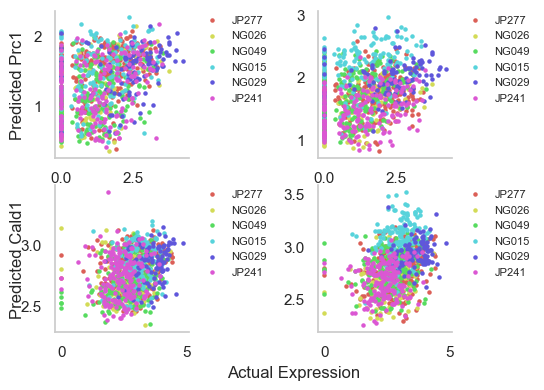

In [24]:
# Scatter actual vs predicted expression with batch highlights.
fig, axes = plt.subplots(2, 2, figsize=(6, 4))  # Adjust figsize as needed

for num, gene in enumerate(genes):
    col = num%2
    ax_seg = axes[col, 0]
    ax_hoechst = axes[col, 1]
    
    expid_seg = [(exp_id,'',adata_seg[adata_seg.obs['exp_id'] == exp_id].obs_names.tolist()) for exp_id in set(adata_seg.obs['exp_id'].tolist())]
    expid_hoechst = [(exp_id,'',adata_seg[adata_seg.obs['exp_id'] == exp_id].obs_names.tolist()) for exp_id in set(adata_seg.obs['exp_id'].tolist())]
    
    colors_seg = sns.color_palette("hls", len(expid_seg))
    expid_seg = [(expid, colors_seg[num], cids) for num, (expid, _, cids) in enumerate(expid_seg)]
    
    colors_h = sns.color_palette("hls", len(expid_hoechst))
    expid_hoechst = [(expid, colors_h[num], cids) for num, (expid, _, cids) in enumerate(expid_seg)]

    predVraw_scatter_high(adata_seg, gene, expid_seg, ax = ax_seg)
    predVraw_scatter_high(adata_hoechst, gene, expid_hoechst, ax = ax_hoechst)
    
    # Format axes commonly 
    for ax_toedit in (ax_seg, ax_hoechst):   
        ax_toedit.legend(
            bbox_to_anchor=(1.05, 1),  
            loc="upper left",          
            borderaxespad=0,
            prop={'size': 8},           
            frameon=False
        )

        ax_toedit.set_xlabel('')
        ax_toedit.set_ylabel('')
        
        ax_toedit.grid(False)
        ax_toedit.spines['right'].set_color('none')
        ax_toedit.spines['top'].set_color('none')
    
    # Add gene names to the very left.
    ax_seg.text(
        -0.28,
        0.5,
        f'Predicted {gene}',
        rotation=90,
        va='center',
        ha='center',
        transform=ax_seg.transAxes
    )
    
plt.tight_layout(h_pad=0, w_pad=0.5, pad = 1.5)
fig.supxlabel('Actual Expression',size = 12, x=0.55)  # common x-axis label
plt.savefig(f'{output_fig_path}/ML_Scatter_PredVsActual_Batch.pdf', transparent=True, bbox_inches = 'tight') 
plt.show()

Gene set enrichment analysis for genes that are performing > 2-fold better than the angular model. 

First define 2 utility functions for term formatting and the enrichment itself

### Figure5I/J/K: Interpretability of the cell shape model by cell circularity and cell area

Interpretability approaches for the Cell Shape model
- Cell 1: Definition utility function to retrieve predictions from adata object.
- Cell 2: Data loading of the raw imaging data.
- Cell 3: Calculate size and circularity features over all white listed cells.

In [25]:
# Helper function to retrieve expression predicionts for one gene
def get_preddict(gene, adata):
    gene_idx = np.where(adata.var_names == gene)[0][0]
    pred = adata.layers['pred'][:, gene_idx]

    cid_list = adata.obs_names.tolist()
    pred_dict = dict(zip(cid_list, pred))
    return pred_dict

In [28]:
# We only load segmentation mask
ch_key = 'seg'

# Dict for data loading. key: channel str(), value: list of images (np.array)
channel_dict = {}

with h5py.File(ds_dir,'r+') as h5set:
    # Iterate over all cells in the dataset, key -> cell id
    for key in h5set.keys():
        # in Dataset 3 planes are present. [1] is middle plane.
        plane_id = list(h5set[key][ch_key].keys())[1]
        # loads np.array and adds it to the dictionary of channels
        channel_dict[key] = h5set[key][ch_key][plane_id][()]

In [29]:
data_dict = {'id':[], 'size':[], 'peri':[], 'circ':[]}

for cid in white_list:
    if cid not in channel_dict.keys(): continue
    img = channel_dict[cid]
    contours, hierarchy = cv2.findContours(img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    # Cells with no segmentation mask get discarded
    if not contours: continue
    
    cnt = contours[0]
    
    area = cv2.contourArea(cnt)     # Calculate area (size)
    perimeter = cv2.arcLength(cnt, True) # Calculate perimeter (circumference)
    
    if perimeter != 0:
        circularity = 4 * np.pi * (area / (perimeter * perimeter))
    else:
        circularity = 0
        
    x, y, w, h = cv2.boundingRect(cnt)
        
    data_dict['id'].append(cid)
    data_dict['size'].append(area)
    data_dict['peri'].append(perimeter)
    data_dict['circ'].append(circularity)

morph_meas_df = pd.DataFrame.from_dict(data_dict)

In [30]:
morph_meas_df = morph_meas_df[morph_meas_df['size'] > 5000]

### Figure5K: Predicted expression vs circularity and size
1. Cell 1: Attach prediction for 4 selected genes to the data dict containing morphology measurements.
2. Cell 2: Plot the predictions agains morphology measurments.

In [31]:
selected_genes = ['Top2a', 'Cald1', 'Sox9', 'Erdr1']
plot_df = morph_meas_df.copy()

for gene in selected_genes:
    gene_pred = get_preddict(gene, adata_seg)
    plot_df [gene+'_pred'] = plot_df['id'].map(gene_pred)

value_cols = [gene + '_pred' for gene in selected_genes]

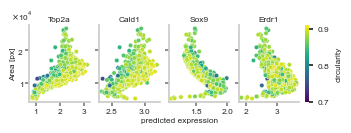

In [32]:
# Visualize cell shape predictions against cell area and circularity.
fig, axes = plt.subplots(1, len(value_cols), sharey=True, figsize=(4, 1))

for plt_id, (ax, col) in enumerate(zip(axes, value_cols)):
    sns.scatterplot(data = plot_df, 
                    x = col, 
                    y = 'size', 
                    hue='circ', 
                    palette="viridis", 
                    s=10, 
                    ax=ax,
                    legend = False)
    ax.set_title(col.replace('_pred',''), size=6, pad=3)
    ax.set_xlabel('')
    ax.grid(False)

    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')

    formatter = ScalarFormatter(useMathText=True, useOffset=False)
    formatter.set_powerlimits((-3, 3))

    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.get_offset_text().set_visible(False)
    ax.yaxis.get_offset_text().set_fontsize(6)
    ax.yaxis.get_offset_text().set_x(-0.3)
    
    ax.tick_params(axis='y', labelsize=6, pad=1, length=3)
    ax.tick_params(axis='x', labelsize=6, pad=1, length=3)
  
    if plt_id ==0:
        ax.tick_params(axis="y", which="both", left=True, right=False, labelleft=True, color = 'grey')
        ax.set_ylabel('Area [px]', size=6, labelpad=1)
    else:
        ax.tick_params(axis="y", which="both", left=True, right=False, labelleft=False, color = 'grey')
        
    ax.tick_params(axis="x", which="both", bottom=True, top=False, labelbottom=True, color = 'grey')

plt.subplots_adjust(wspace=0.1, right=0.85)

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(plot_df["circ"].min(), plot_df["circ"].max()))
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.05, pad=0.04)
cbar.set_label("circularity", size=6)
cbar.ax.tick_params(labelsize=6,length=3)  

for spine in cbar.ax.spines.values():
    spine.set_visible(False)

fig.supxlabel("predicted expression", y=-0.10, size = 6)
plt.subplots_adjust(wspace=0.15, right=0.8)

plt.savefig(f'{output_fig_path}/ML_Scatter_PredVsSizeCirc.pdf', transparent=True, bbox_inches = 'tight') 
plt.show()

### Linear model for Figure 5 I/J

1. Cell 1: Fit liner model for size and circularity against cell shape model expression predictions
2. Cell 2: Visualize model coefficients (Figure5J)
3. Cell 3: How well are cell shape model predictions explained by circularity and shape (Figure5I)

In [33]:
# Fit linear model
rel_gene_df = all_feat_df
top_seg = rel_gene_df.sort_values(by=('avg_Pearson', 'Segmentation'), ascending=False).head(100).index.tolist()
data_dict = pd.DataFrame.from_dict(data_dict)

cor = pd.DataFrame(columns=['gene', 'cor', 'cof1', 'cof2'])

for gene in top_seg:
    data_df = morph_meas_df.copy()
    pred_dict = get_preddict(gene, adata_seg) # ERROR
    data_df['pred'] = data_df['id'].map(pred_dict)
    df_clean = data_df.dropna(subset=['pred'])

    corvars = ['size','circ']
    X = df_clean[corvars]
    y = df_clean['pred']

    model = LinearRegression()
    model.fit(X, y)

    df_clean = df_clean.copy()
    df_clean['predicted'] = model.predict(df_clean[corvars])

    correlation = df_clean['pred'].corr(df_clean['predicted'])
    
    row = {'gene': gene, 'cor': correlation, 'cof1': model.coef_[0],'cof2': model.coef_[1]}

    cor.loc[len(cor)] = row

print(cor)

         gene       cor      cof1      cof2
0        Prc1  0.825077  0.000100  7.675355
1       Top2a  0.815018  0.000121  9.901891
2      Nusap1  0.845568  0.000063  4.590678
3        Cdk1  0.852240  0.000063  4.675496
4       Kif11  0.850821  0.000048  3.257623
..        ...       ...       ...       ...
95       Gas7  0.860636 -0.000028 -0.675485
96      Cald1  0.816607  0.000037  3.685213
97  Hist1h2ae  0.635192  0.000027  3.261406
98      Gstp1  0.762733  0.000015  1.675990
99      Fbln5  0.817220  0.000018  1.771598

[100 rows x 4 columns]


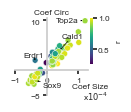

In [34]:
# Visualize Model coefficients
fig, ax = plt.subplots(figsize=(1, 1))
sns.scatterplot(data=cor, x='cof1', y='cof2', hue='cor', palette='viridis',size=5, legend=False, ax=ax)

hightlight_genes = ['Top2a', 'Cald1', 'Sox9', 'Erdr1']

# Add labels from a column, e.g., 'id'
texts = []
for i in range(len(cor)):
    if cor['gene'].iloc[i] in hightlight_genes:
        text = ax.text(
            x=cor['cof1'].iloc[i],
            y=cor['cof2'].iloc[i],
            s=str(cor['gene'].iloc[i]),
            fontsize=6
        )
        texts.append(text)

adjust_text(texts, x=cor.cof1, y=cor.cof2, expand=(2,2), arrowprops=dict(arrowstyle='->', color='black', lw=0.5), force_text=(0.7, 0.7))     
        
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.set_xlabel('')
ax.set_ylabel('')

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3)) 

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.xaxis.offsetText.set_visible(False) 

ax.set_xticks([t for t in ax.get_xticks() if (t >= 0 and t < 0.0002)] + [-0.0001])
ax.set_yticks([t for t in ax.get_yticks() if t != 0 and t <= 10 and t > -7] + [-5])

ax.tick_params(axis='y', labelsize=6, pad=1, length=3)
ax.tick_params(axis='x', labelsize=6, pad=1, length=3)

xmax = ax.get_xlim()[1]
ymax = ax.get_ylim()[1]

ax.text(xmax + xmax * 0.5, -6.5, 'Coef Size\nx$10^{-4}$', ha='right', va='bottom', fontsize=6, linespacing=1)
ax.text(-xmax * 0.3, ymax+1.7, f'Coef Circ', ha='left', va='top', fontsize=6, rotation=0)

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(cor["cor"].min(), 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", anchor=(1.2,1), fraction=0.03, pad=0.03)
cbar.set_label("r", size=6)
cbar.ax.tick_params(labelsize=6,length=3, pad = 1)

for spine in cbar.ax.spines.values():
    spine.set_visible(False)

plt.grid(False)
plt.savefig(f'{output_fig_path}/ML_Scatter_LinRegCoef.pdf', transparent=True, bbox_inches = 'tight') 
plt.show()

### Figure 5I: How well are CNN-based predictions explained per gene by circularity and size?

Fraction of all 73/100 genes predicted above r2 0.75: 0.73


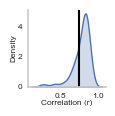

In [35]:
# Evaluation of model performance 
plt.figure(figsize=(1, 1))
sns.kdeplot(cor['cor'], fill=True)

thresh = 0.75
above = (cor['cor'] > thresh).sum()
total = len(cor['cor'])
frac_above = above/total
print(f'Fraction of all {above}/{total} genes predicted above r2 {thresh}: {frac_above}')

plt.title('')
plt.xlabel('Correlation (r)', size=6, labelpad=1)
plt.ylabel('Density', size=6, labelpad=1)
plt.grid(False)

ax = plt.gca()
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.tick_params(axis='y', labelsize=6, pad=1, length=3)
ax.tick_params(axis='x', labelsize=6, pad=1, length=3)

plt.axvline(x=0.75, c='black')

plt.savefig(f'{output_fig_path}/ML_Density_LinRegPerformance.pdf', transparent=True, bbox_inches = 'tight') 
plt.show()